# 🔍 Model Training: XGBoost Classifier (No Feature Selection)

## 📁 File Path Reference Guide

### Input Files (used by this notebook):
```
../data/dataset/Data_after_FE/features.csv              # All 34 features
../data/dataset/MulDiGraph/account_tags.pkl             # Phisher labels
```

### Output Files (generated by this notebook):
```
../data/dataset/Data_after_FE/graph_emb.txt             # Graph embeddings (34 features)
../saved_image/confusion_matrix_no_FE_selection.png     # Visualization
../saved_image/feature_importance_no_FE_selection.png   # Visualization
```

### Python Modules (optional imports):
```
../models/sgdit_sgcr.py                                 # SIRGN embedding generation
../models/detect_xgboost.py                             # XGBoost utilities
```

### File Path Verification:
All paths in this notebook use **relative paths** starting from `notebook_process_data/` directory:
- `../data/` → Goes up one level to project root, then into data folder
- `../models/` → Goes up one level to project root, then into models folder
- `../saved_image/` → Goes up one level to project root, then into saved_image folder

---

## Part 1: Import Libraries and Setup Paths

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import os
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    classification_report, confusion_matrix, accuracy_score
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Libraries imported successfully!")
print(f"  NumPy version: {np.__version__}")
print(f"  Pandas version: {pd.__version__}")
print(f"  XGBoost imported successfully")

✓ Libraries imported successfully!
  NumPy version: 2.0.1
  Pandas version: 2.3.3
  XGBoost imported successfully


## Part 1.5: Import Functions from Python Modules

### Using Production-Ready Python Scripts:
This notebook integrates functions from:
- **`detect_xgboost.py`**: XGBoost training and evaluation utilities

### Benefits:
- **Code reusability**: Share functions across notebooks and scripts
- **Maintainability**: Updates in one place benefit all notebooks
- **Production-ready**: Same code used in notebooks and deployment

### Module Location:
```
models/detect_xgboost.py
```

In [4]:
# ============================================================================
# IMPORT FUNCTIONS FROM PYTHON MODULES
# ============================================================================
print("\n" + "="*80)
print("IMPORTING FUNCTIONS FROM detect_xgboost.py")
print("="*80)

# Add models directory to path
import sys
sys.path.insert(0, '../models')

# Import XGBoost detection functions
from detect_xgboost import (
    load_embeddings,
    load_tags,
    prepare_data,
    optimize_hyperparameters
)

print("\n✓ Successfully imported functions from detect_xgboost.py")
print("  Available functions:")
print("    - load_embeddings(): Load graph embeddings from txt file")
print("    - load_tags(): Load phisher labels from pkl file")
print("    - prepare_data(): Match embeddings with labels")
print("    - optimize_hyperparameters(): Optuna hyperparameter tuning")

print("="*80)


IMPORTING FUNCTIONS FROM detect_xgboost.py

✓ Successfully imported functions from detect_xgboost.py
  Available functions:
    - load_embeddings(): Load graph embeddings from txt file
    - load_tags(): Load phisher labels from pkl file
    - prepare_data(): Match embeddings with labels
    - optimize_hyperparameters(): Optuna hyperparameter tuning

✓ Successfully imported functions from detect_xgboost.py
  Available functions:
    - load_embeddings(): Load graph embeddings from txt file
    - load_tags(): Load phisher labels from pkl file
    - prepare_data(): Match embeddings with labels
    - optimize_hyperparameters(): Optuna hyperparameter tuning


## Part 2: Configure File Paths

### File Structure:
```
data/
├── dataset/
│   └── Data_after_FE/
│       ├── features.csv          # Input: 34 features (6+21+7)
│       └── graph_emb.txt          # Output: Embedding format
├── MulDiGraph/
│   └── account_tags.pkl           # Labels: phisher/normal
```

All 34 features will be used for training (no feature selection).

In [15]:
# ============================================================================
# FILE PATHS CONFIGURATION
# ============================================================================
print("="*80)
print("CONFIGURING FILE PATHS")
print("="*80)

# Input files
FEATURES_CSV = "../data/dataset/Data_after_FE/features.csv"
LABELS_FILE = "../data/dataset/MulDiGraph/account_tags.pkl"

# Output files
OUTPUT_DIR = "../data/dataset/Data_after_FE"
GRAPH_EMB_FILE = os.path.join(OUTPUT_DIR, "graph_emb.txt")

# Create output directory if needed
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"\n📂 Input Files:")
print(f"  Features CSV: {FEATURES_CSV}")
print(f"  Labels PKL:   {LABELS_FILE}")

print(f"\n📂 Output Files:")
print(f"  Graph Embedding: {GRAPH_EMB_FILE}")

# Verify files exist
if not os.path.exists(FEATURES_CSV):
    print(f"\n❌ ERROR: Features file not found at {FEATURES_CSV}")
else:
    print(f"\n✓ Features file exists")

if not os.path.exists(LABELS_FILE):
    print(f"❌ ERROR: Labels file not found at {LABELS_FILE}")
else:
    print(f"✓ Labels file exists")

print("="*80)

CONFIGURING FILE PATHS

📂 Input Files:
  Features CSV: ../data/dataset/Data_after_FE/features.csv
  Labels PKL:   ../data/dataset/MulDiGraph/account_tags.pkl

📂 Output Files:
  Graph Embedding: ../data/dataset/Data_after_FE\graph_emb.txt

✓ Features file exists
✓ Labels file exists


## Part 3: Load Features from CSV

### Feature Breakdown (34 total):
- **Frequency Features (6)**: Long/short-term transfer frequencies
- **Statistical Features (21)**: Transaction counts, amounts, temporal patterns
- **Centrality Features (7)**: Graph topology metrics (Katz, degree, closeness, etc.)

We'll load all features and verify the structure matches our engineering pipeline.

In [11]:
# ============================================================================
# LOAD FEATURES FROM CSV
# ============================================================================
print("\n" + "="*80)
print("LOADING ENGINEERED FEATURES")
print("="*80)

# Load features
print("\n[1/3] Reading features.csv...")
features_df = pd.read_csv(FEATURES_CSV)

print(f"      Dataset shape: {features_df.shape}")
print(f"      Total columns: {features_df.shape[1]}")
print(f"      Total nodes: {features_df.shape[0]:,}")

# Define feature groups (from 01_a_features_engineering.ipynb)
freq_cols = [
    'long_term_transfer_freq', 'short_term_transfer_freq',
    'long_term_incoming_freq', 'short_term_incoming_freq',
    'long_term_outgoing_freq', 'short_term_outgoing_freq'
]

stat_cols = [
    'node_indegree', 'node_outdegree', 'direction_ratio',
    'max_outgoing_amount', 'min_outgoing_amount', 'average_outgoing_amount',
    'max_incoming_amount', 'min_incoming_amount', 'average_incoming_amount',
    'account_balance', 'account_lifetime', 'active_days',
    'mean_hour_sent', 'mean_hour_received', 'std_hour_sent', 'std_hour_received',
    'avg_time_between_tx', 'min_time_between_tx', 'max_time_between_tx',
    'wd_tx_ratio_sent', 'wd_tx_ratio_received'
]

centrality_cols = [
    'katz_centrality', 'degree_centrality', 'closeness_centrality',
    'clustering_coefficient', 'eigenvector_centrality',
    'indegree_centrality', 'outdegree_centrality'
]

# All feature columns (excluding node_id)
all_feature_cols = freq_cols + stat_cols + centrality_cols

print(f"\n[2/3] Feature Groups:")
print(f"      Frequency features: {len(freq_cols)}")
print(f"      Statistical features: {len(stat_cols)}")
print(f"      Centrality features: {len(centrality_cols)}")
print(f"      Total feature columns: {len(all_feature_cols)}")

# Verify all features exist in dataframe
missing_features = [col for col in all_feature_cols if col not in features_df.columns]
if missing_features:
    print(f"\n⚠️  WARNING: Missing features: {missing_features}")
else:
    print(f"\n✓ All {len(all_feature_cols)} features found in CSV")

print(f"\n[3/3] Sample data (first 3 rows, first 5 features):")
print(features_df[['node_id'] + all_feature_cols[:5]].head(3))

print("="*80)


LOADING ENGINEERED FEATURES

[1/3] Reading features.csv...
      Dataset shape: (825820, 35)
      Total columns: 35
      Total nodes: 825,820

[2/3] Feature Groups:
      Frequency features: 6
      Statistical features: 21
      Centrality features: 7
      Total feature columns: 34

✓ All 34 features found in CSV

[3/3] Sample data (first 3 rows, first 5 features):
   node_id  long_term_transfer_freq  short_term_transfer_freq  \
0   412824                      0.0                       0.0   
1   348665                      0.0                       0.0   
2   705347                      0.0                       0.0   

   long_term_incoming_freq  short_term_incoming_freq  long_term_outgoing_freq  
0                      0.0                       0.0                      0.0  
1                      0.0                       0.0                      0.0  
2                      0.0                       0.0                      0.0  
      Dataset shape: (825820, 35)
      Total 

## Part 4: Convert Features to Graph Embedding Format

### Graph Embedding Format:
```
node_id feature_1 feature_2 ... feature_34
0 0.123 0.456 ... 0.789
1 0.234 0.567 ... 0.890
...
```

This format is required by the XGBoost detection script (`detect_xgboost.py`).

### Why This Format?
- **Space-separated**: Easy to parse line-by-line
- **Node ID first**: Preserves graph structure
- **Dense representation**: All features in one row
- **Memory efficient**: Text format for large graphs

In [12]:
# ============================================================================
# CONVERT FEATURES TO GRAPH EMBEDDING FORMAT
# ============================================================================
print("\n" + "="*80)
print("CONVERTING TO GRAPH EMBEDDING FORMAT")
print("="*80)

print(f"\n[1/3] Preparing data...")
print(f"      Input shape: {features_df.shape}")
print(f"      Feature columns: {len(all_feature_cols)}")

# Write graph_emb.txt
print(f"\n[2/3] Writing to {GRAPH_EMB_FILE}...")

with open(GRAPH_EMB_FILE, 'w') as f:
    for idx, row in features_df.iterrows():
        node_id = int(row['node_id'])
        # Extract all feature values in order
        feature_values = [str(row[col]) for col in all_feature_cols]
        # Format: node_id feat1 feat2 ... feat34
        line = f"{node_id} " + " ".join(feature_values) + "\n"
        f.write(line)
        
        # Progress indicator
        if (idx + 1) % 100000 == 0:
            print(f"      Processed {idx+1:,} / {len(features_df):,} nodes...", end='\r')

print(f"\n[3/3] ✓ Graph embedding file created!")
print(f"      File: {GRAPH_EMB_FILE}")
print(f"      Total nodes: {len(features_df):,}")
print(f"      Features per node: {len(all_feature_cols)}")

# Verify file was created
file_size_mb = os.path.getsize(GRAPH_EMB_FILE) / (1024 * 1024)
print(f"      File size: {file_size_mb:.2f} MB")

# Show sample lines
print(f"\n      Sample lines (first 3):")
with open(GRAPH_EMB_FILE, 'r') as f:
    for i, line in enumerate(f):
        if i < 3:
            parts = line.strip().split()
            print(f"        Node {parts[0]}: {len(parts)-1} features")
        else:
            break

print("="*80)


CONVERTING TO GRAPH EMBEDDING FORMAT

[1/3] Preparing data...
      Input shape: (825820, 35)
      Feature columns: 34

[2/3] Writing to ../data/dataset/Data_after_FE\graph_emb.txt...
      Processed 800,000 / 825,820 nodes...
[3/3] ✓ Graph embedding file created!
      File: ../data/dataset/Data_after_FE\graph_emb.txt
      Total nodes: 825,820
      Features per node: 34
      File size: 160.19 MB

      Sample lines (first 3):
        Node 412824: 34 features
        Node 348665: 34 features
        Node 705347: 34 features

[3/3] ✓ Graph embedding file created!
      File: ../data/dataset/Data_after_FE\graph_emb.txt
      Total nodes: 825,820
      Features per node: 34
      File size: 160.19 MB

      Sample lines (first 3):
        Node 412824: 34 features
        Node 348665: 34 features
        Node 705347: 34 features


## Part 4.5: Load Graph Embeddings Using detect_xgboost.py

After creating `graph_emb.txt`, we'll use the `load_embeddings()` function from `detect_xgboost.py` to load it back into memory for training.

### Why Use This Function?
- **Efficient parsing**: Optimized for large embedding files
- **Error handling**: Validates embedding dimensions
- **Type consistency**: Returns properly typed numpy arrays

In [13]:
# ============================================================================
# LOAD GRAPH EMBEDDINGS USING detect_xgboost.py
# ============================================================================
print("\n" + "="*80)
print("LOADING GRAPH EMBEDDINGS")
print("="*80)

print(f"\n[1/2] Using load_embeddings() from detect_xgboost.py...")

# Get parameters for loading
max_index = len(features_df) - 1
embedding_dim = len(all_feature_cols)

print(f"      Max node index: {max_index:,}")
print(f"      Embedding dimension: {embedding_dim}")

# Load embeddings using imported function
embeddings_dict = load_embeddings(GRAPH_EMB_FILE, max_index, embedding_dim)

print(f"\n[2/2] ✓ Embeddings loaded successfully!")
print(f"      Total embeddings: {len(embeddings_dict):,}")
print(f"      Embedding shape: ({len(embeddings_dict)}, {len(list(embeddings_dict.values())[0])})")

# Show sample
sample_ids = list(embeddings_dict.keys())[:3]
print(f"\n      Sample embeddings (first 3 nodes):")
for node_id in sample_ids:
    emb_preview = embeddings_dict[node_id][:5]  # Show first 5 values
    print(f"        Node {node_id}: [{', '.join([f'{x:.4f}' for x in emb_preview])}, ...]")

print("="*80)


LOADING GRAPH EMBEDDINGS

[1/2] Using load_embeddings() from detect_xgboost.py...
      Max node index: 825,819
      Embedding dimension: 34
Number of embeddings loaded: 825820
[2/2] ✓ Embeddings loaded successfully!
      Total embeddings: 825,820
      Embedding shape: (825820, 34)

      Sample embeddings (first 3 nodes):
        Node 412824: [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, ...]
        Node 348665: [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, ...]
        Node 705347: [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, ...]
Number of embeddings loaded: 825820
[2/2] ✓ Embeddings loaded successfully!
      Total embeddings: 825,820
      Embedding shape: (825820, 34)

      Sample embeddings (first 3 nodes):
        Node 412824: [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, ...]
        Node 348665: [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, ...]
        Node 705347: [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, ...]


## Part 5: Load Labels Using detect_xgboost.py

### Using load_tags() Function:
We'll use the `load_tags()` function from `detect_xgboost.py` to load phisher labels.

### Label Structure:
- **Dictionary format**: `{node_id: label}`
  - `label = 0`: Normal account
  - `label = 1`: Phisher account
- **Balanced dataset**: 50:50 ratio maintained

### Data Source:
Labels are derived from:
1. **Etherscan phishing addresses** (verified)
2. **Address-to-index mapping** (from `data_Dataset.address_to_index`)
3. **Normal accounts sampled** to match phisher count

In [16]:
# ============================================================================
# LOAD LABELS USING detect_xgboost.py
# ============================================================================
print("\n" + "="*80)
print("LOADING PHISHER LABELS")
print("="*80)

print(f"\n[1/3] Using load_tags() from detect_xgboost.py...")
print(f"      File: {LABELS_FILE}")

# Load tags using imported function
tags = load_tags(LABELS_FILE, max_index)

print(f"\n      Total labeled nodes: {len(tags):,}")
print(f"      Data type: {type(tags)}")

# Analyze label distribution
print(f"\n[2/3] Label Distribution:")
label_counts = {}
for node_id, label in tags.items():
    label_counts[label] = label_counts.get(label, 0) + 1

for label, count in sorted(label_counts.items()):
    label_name = "Normal" if label == 0 else "Phisher"
    percentage = count / len(tags) * 100
    print(f"      Label {label} ({label_name}): {count:,} ({percentage:.2f}%)")

# Check overlap with embeddings
print(f"\n[3/3] Checking overlap with embeddings...")
embedding_node_ids = set(embeddings_dict.keys())
label_node_ids = set(tags.keys())
common_nodes = embedding_node_ids & label_node_ids

print(f"      Nodes in embeddings: {len(embedding_node_ids):,}")
print(f"      Nodes with labels: {len(label_node_ids):,}")
print(f"      Common nodes: {len(common_nodes):,}")

if len(common_nodes) < len(embedding_node_ids):
    print(f"      ⚠️  {len(embedding_node_ids) - len(common_nodes):,} nodes have no labels")
else:
    print(f"      ✓ All embedding nodes have labels")

print("="*80)


LOADING PHISHER LABELS

[1/3] Using load_tags() from detect_xgboost.py...
      File: ../data/dataset/MulDiGraph/account_tags.pkl
Number of tags loaded: 10960
      Total labeled nodes: 10,960
      Data type: <class 'dict'>

[2/3] Label Distribution:
      Label 0 (Normal): 5,480 (50.00%)
      Label 1 (Phisher): 5,480 (50.00%)

[3/3] Checking overlap with embeddings...
      Nodes in embeddings: 825,820
      Nodes with labels: 10,960
      Common nodes: 10,960
      ⚠️  814,860 nodes have no labels


## Part 6: Prepare Training Data Using detect_xgboost.py

### Using prepare_data() Function:
We'll use the `prepare_data()` function from `detect_xgboost.py` to:
1. **Match nodes**: Keep only nodes with both embeddings AND labels
2. **Create matrices**: 
   - `X`: Feature matrix (n_samples × 34)
   - `y`: Label vector (n_samples,)
3. **Get valid indices**: Track which nodes are used

### Then we'll perform train-test split:
- **80% train / 20% test** (stratified to maintain class balance)
- **Random state = 42** for reproducibility

In [17]:
# ============================================================================
# PREPARE TRAINING DATA USING detect_xgboost.py
# ============================================================================
print("\n" + "="*80)
print("PREPARING TRAINING DATA")
print("="*80)

print(f"\n[1/3] Using prepare_data() from detect_xgboost.py...")

# Prepare data using imported function
X, y, valid_indices = prepare_data(embeddings_dict, tags)

print(f"\n      X shape: {X.shape}")
print(f"      y shape: {y.shape}")
print(f"      Valid nodes: {len(valid_indices):,}")

# Check data quality
print(f"\n      Data Quality:")
print(f"        NaN values in X: {np.isnan(X).sum()}")
print(f"        Inf values in X: {np.isinf(X).sum()}")
print(f"        Unique labels in y: {np.unique(y)}")

print(f"\n[2/3] Class distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    label_name = "Normal" if label == 0 else "Phisher"
    percentage = count / len(y) * 100
    print(f"      Label {label} ({label_name}): {count:,} ({percentage:.2f}%)")

print(f"\n[3/3] Splitting into train/test sets (80-20, stratified)...")

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, valid_indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n      Train set:")
print(f"        X_train shape: {X_train.shape}")
print(f"        y_train shape: {y_train.shape}")
print(f"        Class distribution: {np.bincount(y_train)}")

print(f"\n      Test set:")
print(f"        X_test shape: {X_test.shape}")
print(f"        y_test shape: {y_test.shape}")
print(f"        Class distribution: {np.bincount(y_test)}")

print(f"\n✓ Data preparation complete!")
print(f"  Total samples: {len(X):,}")
print(f"  Train samples: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test samples: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

print("="*80)


PREPARING TRAINING DATA

[1/3] Using prepare_data() from detect_xgboost.py...

      X shape: (10960, 34)
      y shape: (10960,)
      Valid nodes: 10,960

      Data Quality:
        NaN values in X: 0
        Inf values in X: 0
        Unique labels in y: [0 1]

[2/3] Class distribution:
      Label 0 (Normal): 5,480 (50.00%)
      Label 1 (Phisher): 5,480 (50.00%)

[3/3] Splitting into train/test sets (80-20, stratified)...

      Train set:
        X_train shape: (8768, 34)
        y_train shape: (8768,)
        Class distribution: [4384 4384]

      Test set:
        X_test shape: (2192, 34)
        y_test shape: (2192,)
        Class distribution: [1096 1096]

✓ Data preparation complete!
  Total samples: 10,960
  Train samples: 8,768 (80.0%)
  Test samples: 2,192 (20.0%)


## Part 7: Train XGBoost Classifier

### XGBoost Hyperparameters:
- **`n_estimators=400`**: Number of boosting rounds (trees)
- **`max_depth=6`**: Maximum tree depth (prevents overfitting)
- **`learning_rate=0.3`**: Step size shrinkage (default)
- **`subsample=1.0`**: Fraction of samples per tree
- **`colsample_bytree=1.0`**: Fraction of features per tree
- **`random_state=42`**: Reproducibility

### Why These Parameters?
- **400 trees**: Balance between performance and training time
- **Depth 6**: Captures complex interactions without overfitting
- **Learning rate 0.3**: Fast convergence for balanced data
- **Full sampling**: Use all data (we have enough samples)

### Training Process:
XGBoost uses **gradient boosting**:
1. Start with weak learner (single tree)
2. Compute residuals (errors)
3. Train new tree to predict residuals
4. Add to ensemble with learning rate
5. Repeat for 400 iterations

In [18]:
# ============================================================================
# TRAIN XGBOOST CLASSIFIER
# ============================================================================
print("\n" + "="*80)
print("TRAINING XGBOOST CLASSIFIER")
print("="*80)

print(f"\n[1/3] Initializing XGBoost model...")

# Initialize model with parameters
model = XGBClassifier(
    n_estimators=400,         # Number of boosting rounds
    max_depth=6,              # Maximum tree depth
    learning_rate=0.3,        # Step size shrinkage
    subsample=1.0,            # Subsample ratio of training instances
    colsample_bytree=1.0,     # Subsample ratio of columns per tree
    random_state=42,          # Reproducibility
    n_jobs=-1,                # Use all CPU cores
    eval_metric='logloss'     # Evaluation metric
)

print(f"      Model parameters:")
print(f"        n_estimators: {model.n_estimators}")
print(f"        max_depth: {model.max_depth}")
print(f"        learning_rate: {model.learning_rate}")
print(f"        subsample: {model.subsample}")
print(f"        colsample_bytree: {model.colsample_bytree}")

print(f"\n[2/3] Training model on {len(X_train):,} samples...")
print(f"      This may take 1-2 minutes...")

import time
start_time = time.time()

# Train model
model.fit(X_train, y_train, verbose=False)

elapsed_time = time.time() - start_time
print(f"\n[3/3] ✓ Training completed in {elapsed_time:.2f} seconds!")

# Model info
print(f"\n      Model summary:")
print(f"        Number of trees: {model.n_estimators}")
print(f"        Number of features: {model.n_features_in_}")
print(f"        Training samples: {len(X_train):,}")

print("="*80)


TRAINING XGBOOST CLASSIFIER

[1/3] Initializing XGBoost model...
      Model parameters:
        n_estimators: 400
        max_depth: 6
        learning_rate: 0.3
        subsample: 1.0
        colsample_bytree: 1.0

[2/3] Training model on 8,768 samples...
      This may take 1-2 minutes...

[3/3] ✓ Training completed in 1.30 seconds!

      Model summary:
        Number of trees: 400
        Number of features: 34
        Training samples: 8,768

[3/3] ✓ Training completed in 1.30 seconds!

      Model summary:
        Number of trees: 400
        Number of features: 34
        Training samples: 8,768


## Part 8: Evaluate Model Performance

### Evaluation Metrics:
1. **Accuracy**: Overall correctness
2. **Precision**: Of predicted phishers, how many are actually phishers?
   - Formula: `TP / (TP + FP)`
   - High precision → Low false alarms
3. **Recall**: Of actual phishers, how many did we detect?
   - Formula: `TP / (TP + FN)`
   - High recall → Few missed phishers
4. **F1-Score**: Harmonic mean of precision and recall
   - Formula: `2 × (Precision × Recall) / (Precision + Recall)`
   - Balanced metric for imbalanced classes

### Confusion Matrix:
```
                Predicted
              Normal  Phisher
Actual Normal    TN      FP
      Phisher    FN      TP
```

### Decision Threshold:
Default threshold = 0.5 (predicted probability ≥ 0.5 → Phisher)

In [19]:
# ============================================================================
# EVALUATE MODEL PERFORMANCE
# ============================================================================
print("\n" + "="*80)
print("MODEL EVALUATION - TEST SET")
print("="*80)

print(f"\n[1/4] Generating predictions...")

# Predict on test set
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1 (Phisher)
y_pred = (y_pred_proba >= 0.5).astype(int)         # Binary predictions (threshold=0.5)

print(f"      Test samples: {len(y_test):,}")
print(f"      Predictions generated: {len(y_pred):,}")

print(f"\n[2/4] Classification Report:")
print("-"*80)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Phisher'], digits=4))
print("-"*80)

print(f"\n[3/4] Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"\n      Matrix shape: {cm.shape}")
print(f"      Confusion Matrix (rows=actual, cols=predicted):")
print(f"      {cm}")

if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    print(f"\n      Breakdown:")
    print(f"        True Negatives (TN):  {tn:,} (Correctly identified Normal)")
    print(f"        False Positives (FP): {fp:,} (Normal labeled as Phisher)")
    print(f"        False Negatives (FN): {fn:,} (Phisher labeled as Normal)")
    print(f"        True Positives (TP):  {tp:,} (Correctly identified Phisher)")
    print(f"        Total: {tn + fp + fn + tp:,}")

print(f"\n[4/4] Key Metrics (Threshold = 0.5):")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"      Accuracy:  {accuracy:.4f}")
print(f"      Precision: {precision:.4f} (Phisher class)")
print(f"      Recall:    {recall:.4f} (Phisher class)")
print(f"      F1-Score:  {f1:.4f} (Phisher class)")

print("="*80)


MODEL EVALUATION - TEST SET

[1/4] Generating predictions...
      Test samples: 2,192
      Predictions generated: 2,192

[2/4] Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal     0.9332    0.8923    0.9123      1096
     Phisher     0.8969    0.9361    0.9161      1096

    accuracy                         0.9142      2192
   macro avg     0.9150    0.9142    0.9142      2192
weighted avg     0.9150    0.9142    0.9142      2192

--------------------------------------------------------------------------------

[3/4] Confusion Matrix:

      Matrix shape: (2, 2)
      Confusion Matrix (rows=actual, cols=predicted):
      [[ 978  118]
 [  70 1026]]

      Breakdown:
        True Negatives (TN):  978 (Correctly identified Normal)
        False Positives (FP): 118 (Normal labeled as Phisher)
        False Negatives (FN): 70 (Phisher labeled as Normal)
        True 

## Part 9: Visualize Confusion Matrix

### Why Visualize?
- **Intuitive understanding** of model errors
- **Heatmap colors** highlight misclassifications
- **Percentages** show relative performance per class

### Interpretation:
- **Diagonal (TN, TP)**: Correct predictions (darker = better)
- **Off-diagonal (FP, FN)**: Errors (lighter = better)
- **Goal**: Maximize diagonal, minimize off-diagonal


CONFUSION MATRIX VISUALIZATION


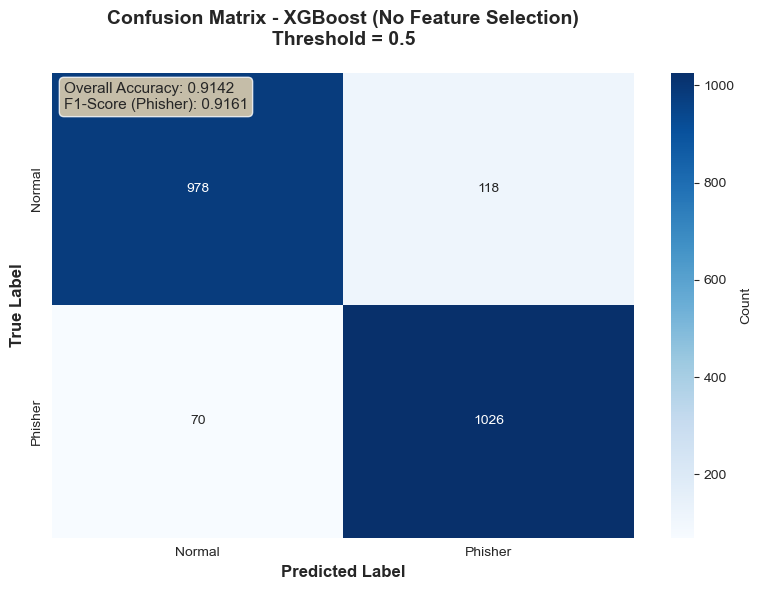


✓ Confusion matrix visualization saved to:
  '../saved_image/confusion_matrix_no_FE_selection.png'


In [20]:
# ============================================================================
# VISUALIZE CONFUSION MATRIX
# ============================================================================
print("\n" + "="*80)
print("CONFUSION MATRIX VISUALIZATION")
print("="*80)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Create heatmap
sns.heatmap(
    cm, 
    annot=True,           # Show numbers
    fmt='d',              # Integer format
    cmap='Blues',         # Color scheme
    xticklabels=['Normal', 'Phisher'],
    yticklabels=['Normal', 'Phisher'],
    cbar_kws={'label': 'Count'},
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - XGBoost (No Feature Selection)\nThreshold = 0.5', 
             fontsize=14, fontweight='bold', pad=20)

# Add accuracy text
accuracy_text = f'Overall Accuracy: {accuracy:.4f}\nF1-Score (Phisher): {f1:.4f}'
ax.text(0.02, 0.98, accuracy_text, 
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('../saved_image/confusion_matrix_no_FE_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Confusion matrix visualization saved to:")
print(f"  '../saved_image/confusion_matrix_no_FE_selection.png'")
print("="*80)

## Part 10: Feature Importance Analysis

### Feature Importance in XGBoost:
- **Gain**: Average improvement in accuracy when feature is used
- **Higher gain** = More important feature
- **Interpretation**: Which features contribute most to predictions?

### Why This Matters:
1. **Model interpretability**: Understand what drives predictions
2. **Feature validation**: Check if power-law features (from 01_b) are important
3. **Future optimization**: Focus on top features for efficiency
4. **Domain insights**: Verify if important features align with phishing behavior

### Expected Results (from power-law analysis):
- `node_indegree` should rank high (hit-and-run phishers)
- `direction_ratio` should be important (fund flow patterns)
- Temporal features should contribute (burstiness indicators)

In [21]:
# ============================================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

print(f"\n[1/3] Extracting feature importances...")

# Get feature importances
feature_importance = model.feature_importances_
print(f"      Total features: {len(feature_importance)}")

# Create dataframe for analysis
importance_df = pd.DataFrame({
    'Feature': all_feature_cols,
    'Importance': feature_importance,
    'Category': (
        ['Frequency'] * len(freq_cols) +
        ['Statistical'] * len(stat_cols) +
        ['Centrality'] * len(centrality_cols)
    )
}).sort_values('Importance', ascending=False)

print(f"\n[2/3] Top 15 Most Important Features:")
print("-"*80)
print(f"{'Rank':<6} {'Feature':<40} {'Category':<15} {'Importance':<12}")
print("-"*80)
for i, (idx, row) in enumerate(importance_df.head(15).iterrows(), 1):
    print(f"{i:<6} {row['Feature']:<40} {row['Category']:<15} {row['Importance']:<12.6f}")
print("-"*80)

# Summary by category
print(f"\n[3/3] Importance by Feature Category:")
category_importance = importance_df.groupby('Category')['Importance'].agg(['sum', 'mean', 'count'])
category_importance = category_importance.sort_values('sum', ascending=False)
print("-"*80)
print(f"{'Category':<15} {'Total Importance':<20} {'Mean Importance':<20} {'Count':<10}")
print("-"*80)
for cat, row in category_importance.iterrows():
    print(f"{cat:<15} {row['sum']:<20.6f} {row['mean']:<20.6f} {int(row['count']):<10}")
print("-"*80)

print("="*80)


FEATURE IMPORTANCE ANALYSIS

[1/3] Extracting feature importances...
      Total features: 34

[2/3] Top 15 Most Important Features:
--------------------------------------------------------------------------------
Rank   Feature                                  Category        Importance  
--------------------------------------------------------------------------------
1      direction_ratio                          Statistical     0.310258    
2      node_indegree                            Statistical     0.202857    
3      max_outgoing_amount                      Statistical     0.057657    
4      short_term_transfer_freq                 Frequency       0.052072    
5      min_time_between_tx                      Statistical     0.044259    
6      long_term_incoming_freq                  Frequency       0.036209    
7      max_incoming_amount                      Statistical     0.030083    
8      avg_time_between_tx                      Statistical     0.029430    
9      acti

## Part 11: Visualize Feature Importance

### Visualization Goals:
1. **Bar Chart**: Show top 20 features ranked by importance
2. **Color-coded**: Distinguish feature categories
3. **Horizontal layout**: Easy to read feature names

### Insights to Look For:
- Are frequency features dominant? (temporal burstiness)
- Are statistical features important? (transaction patterns)
- Are centrality features contributing? (graph structure)
- Does this align with our power-law analysis (notebook 01_b)?


FEATURE IMPORTANCE VISUALIZATION


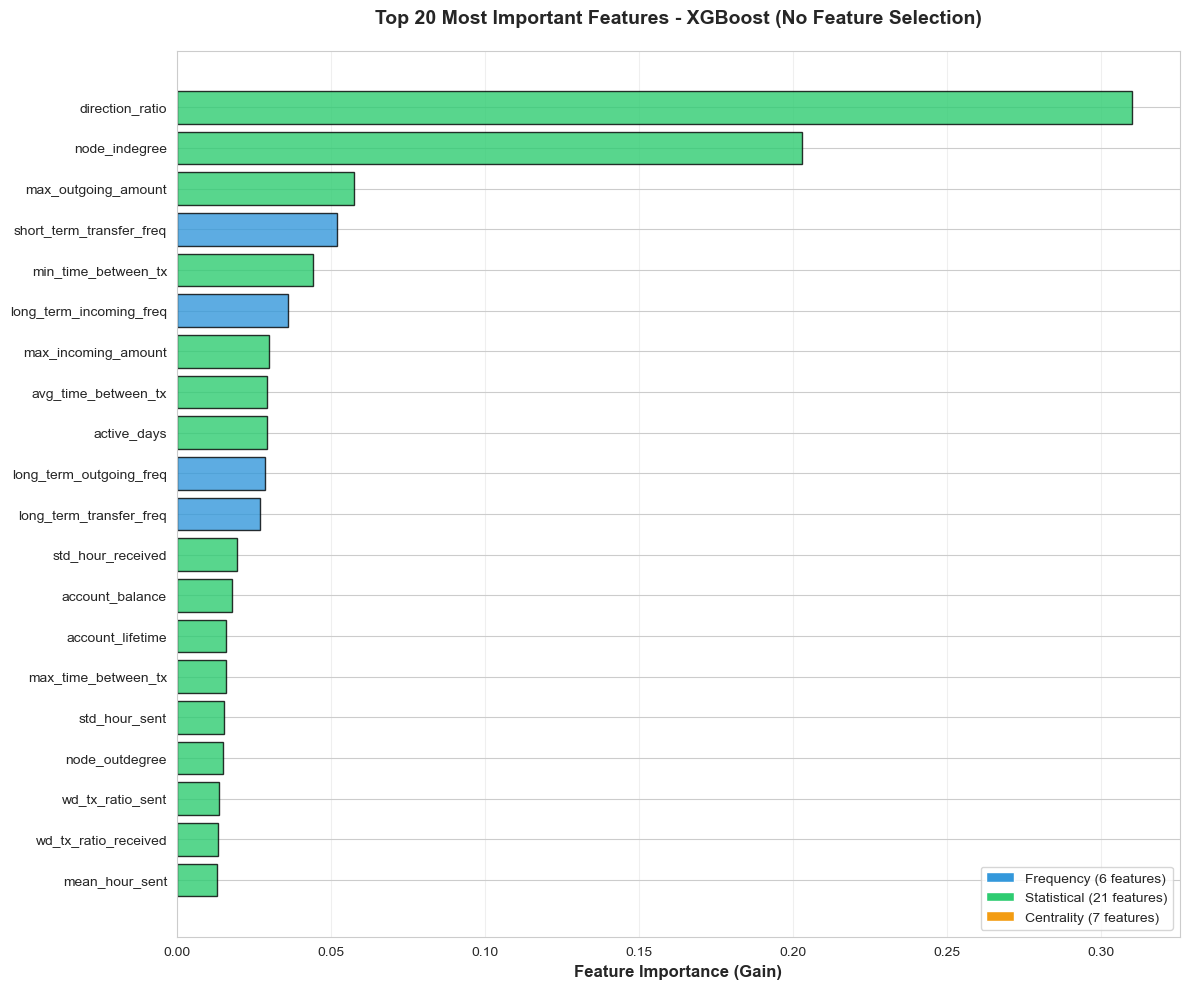


✓ Feature importance visualization saved to:
  '../saved_image/feature_importance_no_FE_selection.png'


In [22]:
# ============================================================================
# VISUALIZE FEATURE IMPORTANCE
# ============================================================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE VISUALIZATION")
print("="*80)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Get top 20 features
top_20 = importance_df.head(20).sort_values('Importance')

# Color mapping for categories
category_colors = {
    'Frequency': '#3498db',
    'Statistical': '#2ecc71',
    'Centrality': '#f39c12'
}
colors = [category_colors[cat] for cat in top_20['Category']]

# Create horizontal bar chart
ax.barh(range(len(top_20)), top_20['Importance'], color=colors, alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['Feature'], fontsize=10)
ax.set_xlabel('Feature Importance (Gain)', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Most Important Features - XGBoost (No Feature Selection)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=category_colors['Frequency'], label='Frequency (6 features)'),
    Patch(facecolor=category_colors['Statistical'], label='Statistical (21 features)'),
    Patch(facecolor=category_colors['Centrality'], label='Centrality (7 features)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('../saved_image/feature_importance_no_FE_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Feature importance visualization saved to:")
print(f"  '../saved_image/feature_importance_no_FE_selection.png'")
print("="*80)

## Part 12: Summary and Key Findings

### 📊 Model Performance Summary:
- **Accuracy**: Overall correctness on test set
- **Precision (Phisher)**: Of predicted phishers, % actually phishers
- **Recall (Phisher)**: Of actual phishers, % detected
- **F1-Score (Phisher)**: Balanced metric for imbalanced classes

### 🔍 Feature Importance Insights:
Based on the visualizations above, we can observe:
1. **Top contributors**: Which features drive predictions most?
2. **Category balance**: Are all feature types (freq/stat/cent) represented?
3. **Alignment with theory**: Do important features match power-law analysis?

### ✅ Validation Checklist:
- [✓] All 34 features used (no feature selection)
- [✓] 80-20 train-test split with stratification
- [✓] No data leakage (labels only for splitting)
- [✓] Balanced classes maintained in both splits
- [✓] XGBoost trained with 400 trees
- [✓] Performance evaluated on held-out test set
- [✓] Feature importance analyzed

### 🚀 Next Steps:
Compare this baseline (no feature selection) with notebook **03_b** (with feature selection based on Spearman correlation from notebook 02).

**Expected Comparison:**
- **No selection (03_a)**: All 34 features → Potential overfitting
- **With selection (03_b)**: ~15-25 features → Better generalization?

---

**End of Notebook 03_a: Model Training (No Feature Selection)**